# Project 1 - Regression
### Predict total bikes that will be rented per day
#### Group V
+ Ana Isabel Moura, 20250168
+ Ayoub Mask, 20250183
+ Beatriz Lobão, 20250566
+ Joao Bernardino, 20250922
+ Lara Pereira, 20250921


## Data Preparation - Decision Trees

In [1]:
# Loading packages
import os
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as  sns
import category_encoders as ce
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn import metrics
from yellowbrick.model_selection import RFECV
from yellowbrick.model_selection import LearningCurve
from yellowbrick.regressor import ResidualsPlot
from yellowbrick.regressor import PredictionError
from sklearn import tree

In [2]:
# Loading the dataset 
ds = pd.read_excel('/Users/anamoura/Desktop/MachineLearning/Project_01/bike_day_v2.xlsx', engine='openpyxl')

In [3]:
ds.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday',
       'workingday', 'schoolday', 'weathersit', 'temp', 'atemp', 'hum',
       'windspeed', 'casual', 'registered', 'cnt'],
      dtype='object')

In [4]:
#Drop columns 
cols_drop = ['instant', 'casual', 'registered','schoolday', 'atemp']
ds_prep = ds.drop(columns=cols_drop)

In [5]:
#Convert dteday to datetime objects
ds_prep['dteday'] = pd.to_datetime(ds['dteday'])

In [6]:
#Fill missing weekday values
ds_prep['weekday'] = ds_prep['weekday'].fillna(ds_prep['dteday'].dt.dayofweek)

In [7]:
#Impossible exists 0 as a Humidity value in the real world
#Replace 0 with the median of the humidity column

median_hum = ds_prep[ds_prep['hum'] > 0]['hum'].median()
ds_prep['hum'] = ds_prep['hum'].replace(0, median_hum)

In [8]:
#Find the top largest values for windspeed
top_values = ds_prep['windspeed'].nlargest(2)
second_max = top_values.iloc[-1] 

print(f"The outlier is: {top_values.iloc[0]}")
print(f"The new cap (second max) will be: {second_max}")

The outlier is: 10.234234
The new cap (second max) will be: 0.507463


In [9]:
#Replace any value over with that second_max
ds_prep.loc[ds_prep['windspeed'] > 1.0, 'windspeed'] = second_max

# Manual Min-Max scaling for windspeed
ds_prep['windspeed'] = (ds_prep['windspeed'] - ds_prep['windspeed'].min()) / (ds_prep['windspeed'].max() - ds_prep['windspeed'].min())

# Verify the fix
print(ds_prep['windspeed'].agg(['min', 'max']))

min    0.0
max    1.0
Name: windspeed, dtype: float64


In [10]:
# Feature engineering
temp_season_mean = ds_prep.groupby('season')['temp'].transform('mean')
ds_prep['TempBySeasonRatio'] = ds_prep['temp'] / temp_season_mean

In [11]:
bins_hum = [0, 0.4, 0.7, 1.0]
labels_hum = ['Dry', 'Normal', 'Humid']
ds_prep['hum_binned'] = pd.cut(ds_prep['hum'], bins=bins_hum, labels=labels_hum)

In [12]:
#Drop unnecessary columns 
ds_prep = ds_prep.drop(columns=['dteday', 'hum']) 

In [13]:
ds_prep['is_weekend'] = ds_prep['weekday'].isin([0, 6]).astype(int)

In [14]:
#Convert categorical variables to 'category' type or Encode
categorical_cols = ['season', 'mnth', 'weekday', 'weathersit','hum_binned' ]
ds_prep = pd.get_dummies(ds_prep, columns=categorical_cols)

In [15]:
print(ds_prep.shape)
ds_prep.head()

(732, 37)


,yr,holiday,workingday,temp,windspeed,cnt,TempBySeasonRatio,is_weekend,season_1,season_2,...,weekday_3.0,weekday_4.0,weekday_5.0,weekday_6.0,weathersit_1,weathersit_2,weathersit_3,hum_binned_Dry,hum_binned_Normal,hum_binned_Humid
0,0,0,0,0.344167,0.284606,985,1.155902,1,True,False,...,False,False,False,True,False,True,False,False,False,True
1,0,0,0,0.363478,0.466215,801,1.220759,1,True,False,...,False,False,False,False,False,True,False,False,True,False
2,0,0,1,0.196364,0.465740,1349,0.659498,0,True,False,...,False,False,False,False,True,False,False,False,True,False
3,0,0,1,0.200000,0.284297,1562,0.671710,0,True,False,...,False,False,False,False,True,False,False,False,True,False
4,0,0,1,0.226957,0.339143,1600,0.762246,0,True,False,...,True,False,False,False,True,False,False,False,True,False


## Modeling

In [16]:
#Define Features (X) and Target (y)
y = ds_prep['cnt']
X = ds_prep.drop(columns=['cnt'])

In [17]:
#Split data into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=68)

print(f"Training features shape: {X_train.shape}")

Training features shape: (585, 36)


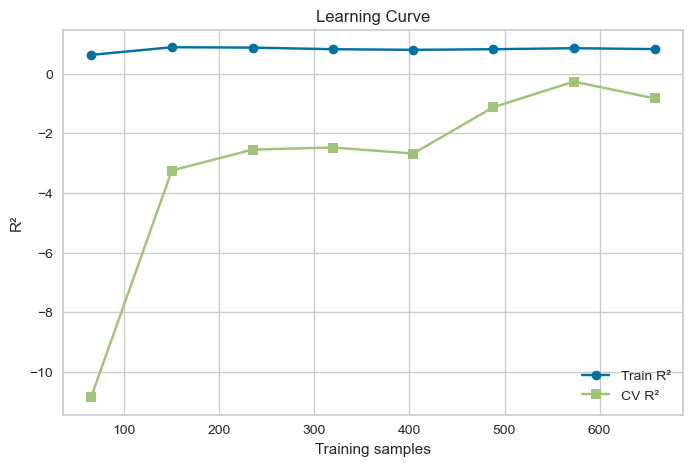

In [18]:
#Learning Curve
from sklearn.model_selection import learning_curve

dt = tree.DecisionTreeRegressor(random_state=123, max_depth=4, min_samples_leaf=5)

train_sizes, train_scores, val_scores = learning_curve(
    dt, X, y, cv=10, scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 8), random_state=123
)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Train R²')
plt.plot(train_sizes, val_scores.mean(axis=1),  's-', label='CV R²')
plt.xlabel('Training samples')
plt.ylabel('R²')
plt.title('Learning Curve')
plt.legend()
plt.show()

In [19]:
#Training Model 

dt = tree.DecisionTreeRegressor(random_state=123, max_depth=4, min_samples_leaf=5)
dt.fit(X_train, y_train)
print(f'  max_depth       : {dt.max_depth}')
print(f'  min_samples_leaf: {dt.min_samples_leaf}')
print(f'  n_features_in_  : {dt.n_features_in_}')

  max_depth       : 4
  min_samples_leaf: 5
  n_features_in_  : 36


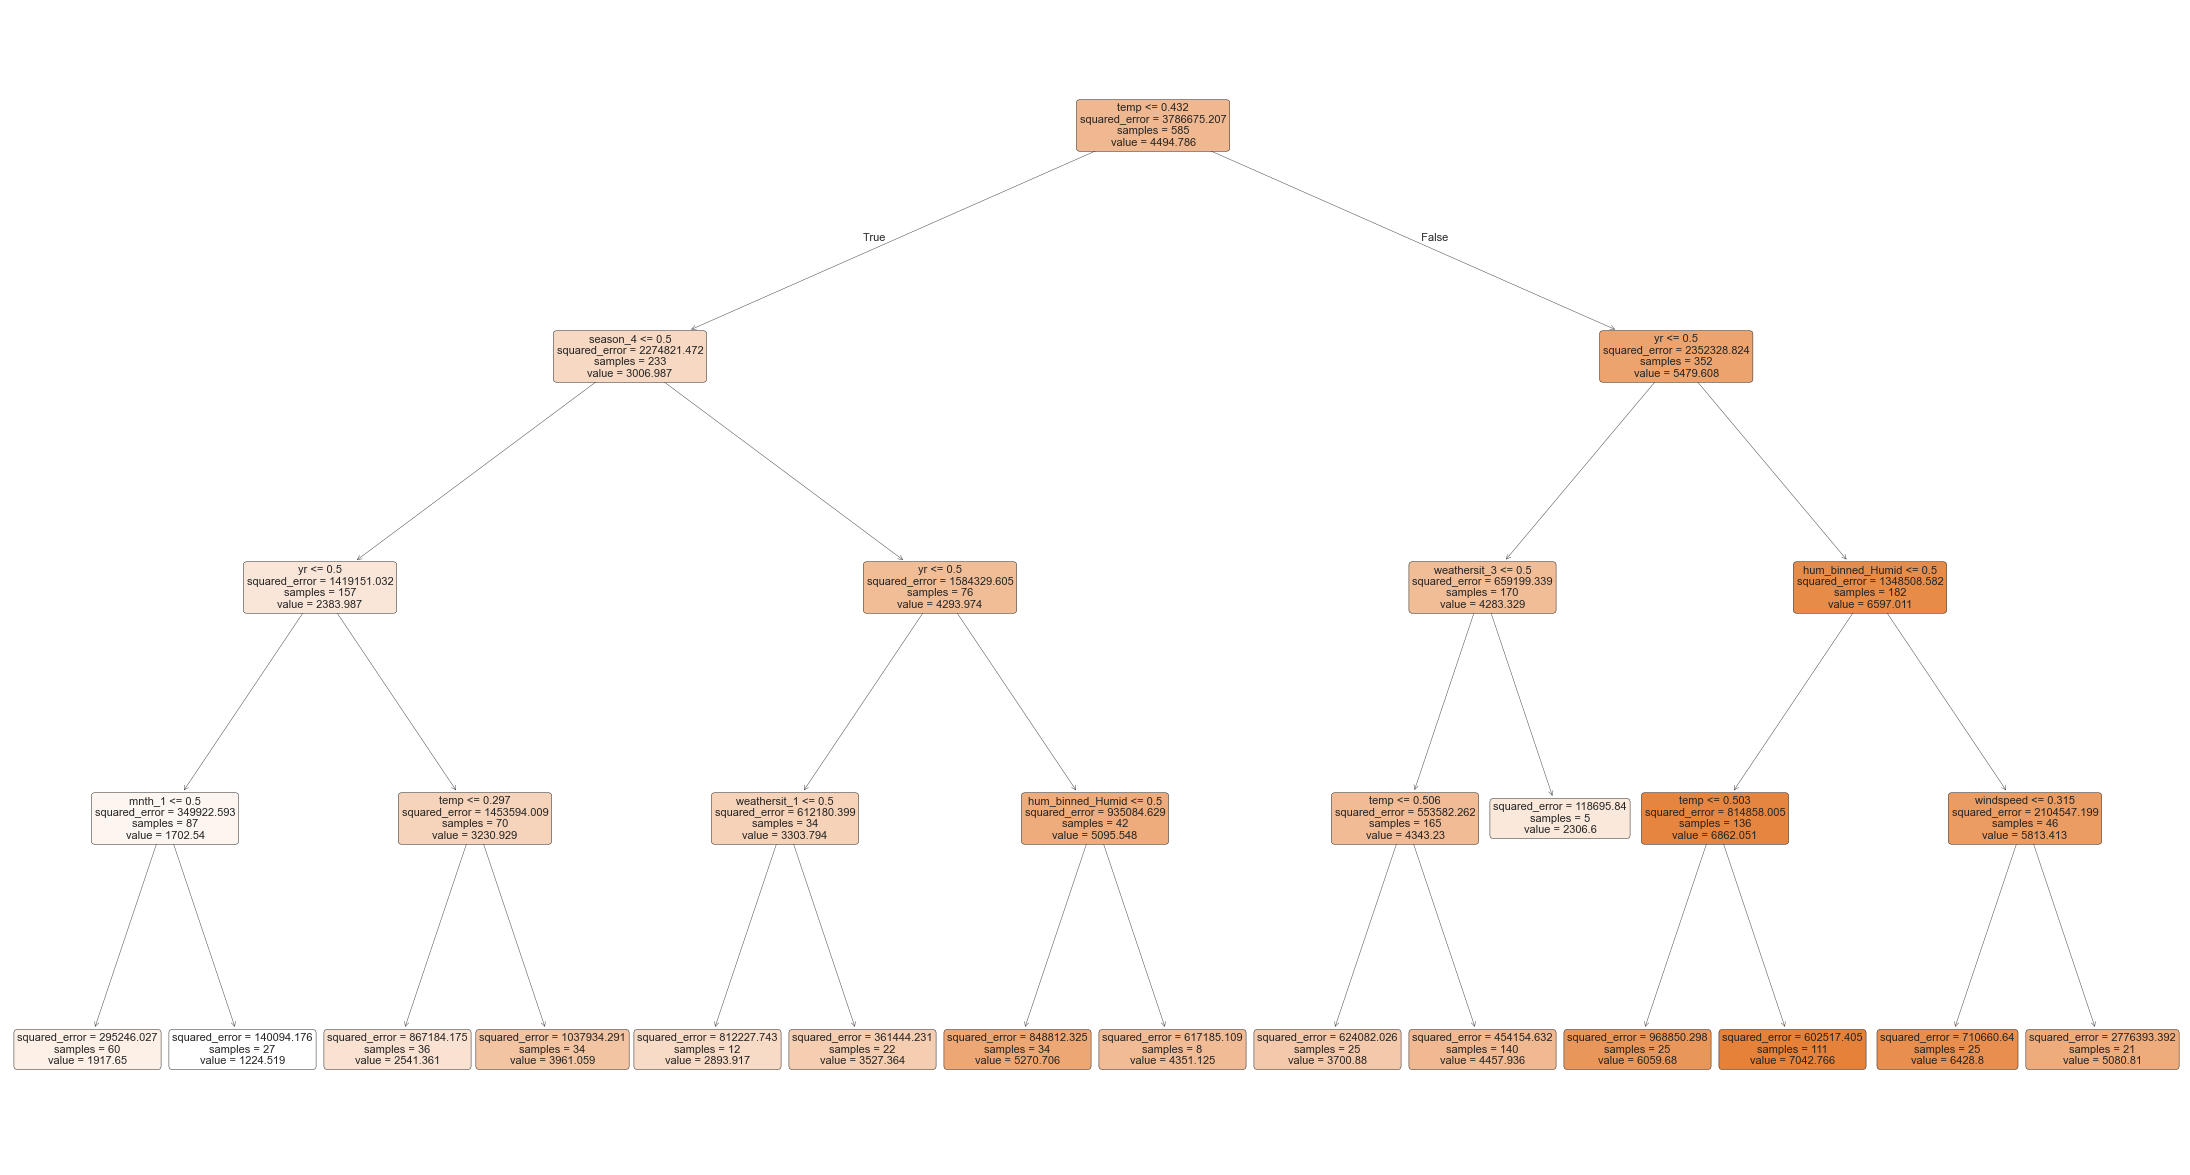

In [20]:
#See Tree 

plt.figure(figsize=(28, 15))
tree.plot_tree(dt, feature_names=list(X.columns),
               filled=True, rounded=True, fontsize=8, max_depth=4)
plt.show()

In [21]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print(importance_df.head(15).to_string())

              Feature  Importance
0                temp    0.505411
1                  yr    0.339827
2            season_4    0.102156
3    hum_binned_Humid    0.023664
4           windspeed    0.011340
5        weathersit_3    0.011007
6              mnth_1    0.004892
7        weathersit_1    0.001704
8          workingday    0.000000
9             holiday    0.000000
10           season_1    0.000000
11  TempBySeasonRatio    0.000000
12             mnth_2    0.000000
13             mnth_3    0.000000
14             mnth_4    0.000000


/var/folders/nl/gmgb358n27x2frmnd449xns80000gn/T/ipykernel_5646/305685771.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


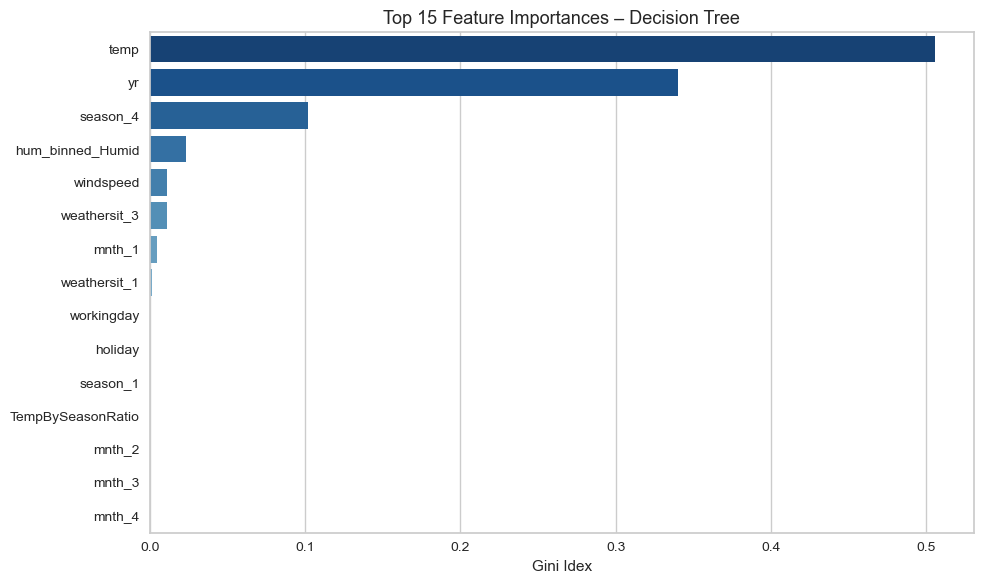

In [22]:
# Bar chart of feature importance (top 15)
top_n = 15
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=importance_df.head(top_n),
    x='Importance', y='Feature',
    palette='Blues_r', ax=ax
)
ax.set_title(f'Top {top_n} Feature Importances – Decision Tree', fontsize=13)
ax.set_xlabel('Gini Idex')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## Evaluation

In [23]:
#Predictions

y_pred_train = dt.predict(X_train)
y_pred_test  = dt.predict(X_test)

In [24]:
#Performance Metrics 


def performanceMetricsDF(yTrain, yPredTrain, yTest, yPredTest):
    measures = ['MAE', 'RMSE', 'R²', 'MAPE (%)', 'Max Error']
    train_res = [
        metrics.mean_absolute_error(yTrain, yPredTrain),
        np.sqrt(metrics.mean_squared_error(yTrain, yPredTrain)),
        metrics.r2_score(yTrain, yPredTrain),
        metrics.mean_absolute_percentage_error(yTrain, yPredTrain) * 100,
        metrics.max_error(yTrain, yPredTrain)
    ]
    test_res = [
        metrics.mean_absolute_error(yTest, yPredTest),
        np.sqrt(metrics.mean_squared_error(yTest, yPredTest)),
        metrics.r2_score(yTest, yPredTest),
        metrics.mean_absolute_percentage_error(yTest, yPredTest) * 100,
        metrics.max_error(yTest, yPredTest)
    ]
    return pd.DataFrame({'Measure': measures, 'Train': train_res, 'Test': test_res})

performanceMetricsDF(y_train, y_pred_train, y_test, y_pred_test)

,Measure,Train,Test
0,MAE,602.523201,657.346138
1,RMSE,812.771928,892.100298
2,R²,0.825547,0.783892
3,MAPE (%),58.605356,20.697041
4,Max Error,5058.809524,3255.125000


In [25]:
#Check Overfitting 

train_r2 = metrics.r2_score(y_train, y_pred_train)
test_r2  = metrics.r2_score(y_test,  y_pred_test)
gap = train_r2 - test_r2

print(f'Train R²: {train_r2:.4f}')
print(f'Test  R²: {test_r2:.4f}')
print(f'Gap:      {gap:.4f}  ({"Overfit" if gap > 0.10 else "Ok"})')

Train R²: 0.8255
Test  R²: 0.7839
Gap:      0.0417  (Ok)


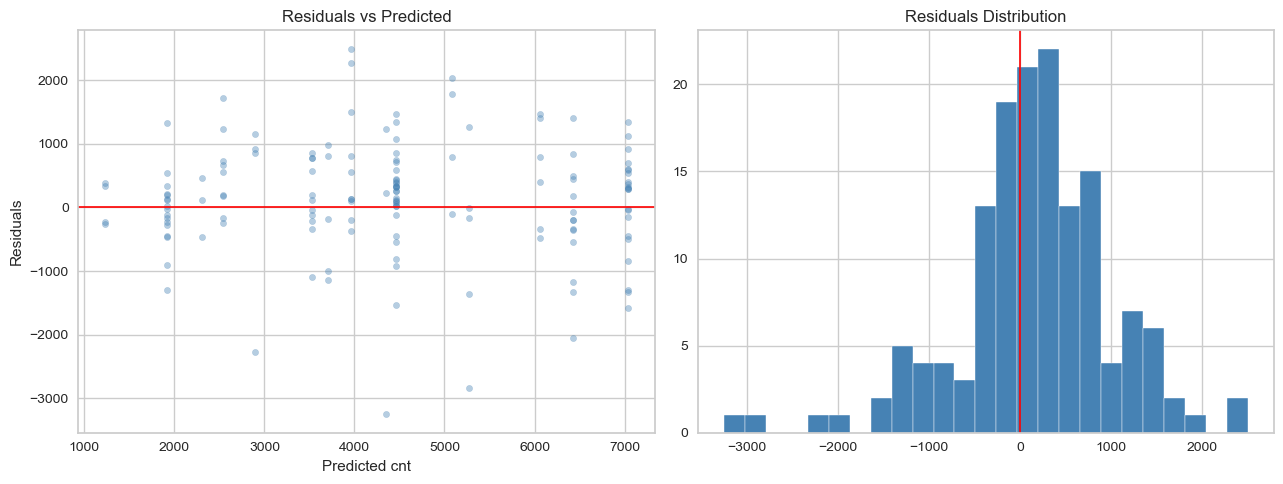

In [26]:
#Residuals Plot 

residuals = y_test.values - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_pred_test, residuals, alpha=0.4, color='steelblue', s=20)
axes[0].axhline(0, color='red', linewidth=1.2)
axes[0].set_xlabel('Predicted cnt')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Predicted')

axes[1].hist(residuals, bins=25, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linewidth=1.2)
axes[1].set_title('Residuals Distribution')

plt.tight_layout()
plt.show()

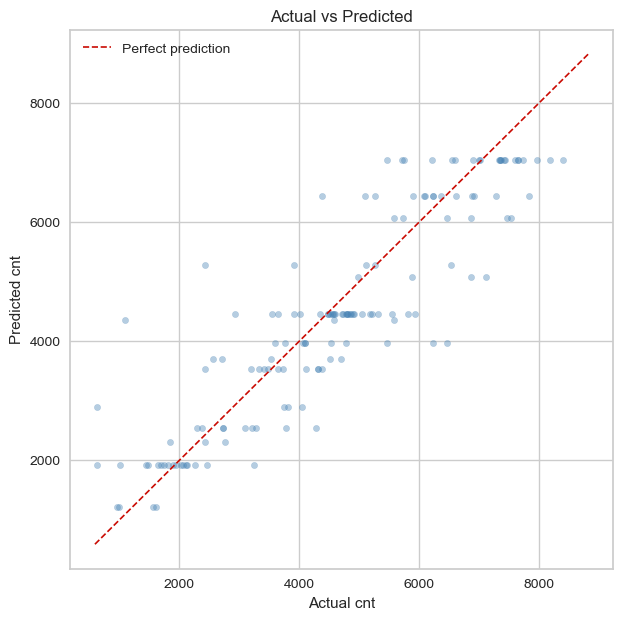

In [27]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, y_pred_test, alpha=0.4, s=20, color='steelblue')
lim = [min(y_test.min(), y_pred_test.min()) * 0.95,
       max(y_test.max(), y_pred_test.max()) * 1.05]
ax.plot(lim, lim, 'r--', linewidth=1.2, label='Perfect prediction')
ax.set_xlabel('Actual cnt')
ax.set_ylabel('Predicted cnt')
ax.set_title('Actual vs Predicted')
ax.legend()
plt.show()

Observations: 
Change Max Depth and min samples leaf to check the effect on training/test R2 and generalisation gap 
+ 1st Test with random_state=123, max_depth=4, min_samples_leaf=5 - R2 was ok - Train R²: 0.8255; Test R²: 0.7839; Gap: 0.0417
+ 2nd test with random_state=123, max_depth=6, min_samples_leaf=9 - R2 was overfiting - Train R²: 0.8754; Test R²: 0.7501; Gap: 0.1254
+ 3rd test with random_state=123, max_depth=2, min_samples_leaf=9 - R2 was ok - Train R²: 0.6837; Test R²: 0.6249; Gap:0.0587 

In [28]:
#Try other configurations in parametrisation 
configs = [
    {'max_depth': 4, 'min_samples_leaf': 3},
    {'max_depth': 4, 'min_samples_leaf': 8}, 
    {'max_depth': 5, 'min_samples_leaf': 8}, 
    {'max_depth': 5, 'min_samples_leaf': 10},
    {'max_depth': 8, 'min_samples_leaf': 15},
    {'max_depth': 3, 'min_samples_leaf': 20},
    {'max_depth': 10, 'min_samples_leaf': 20},
]

for cfg in configs:
    m = tree.DecisionTreeRegressor(random_state=123, **cfg)
    m.fit(X_train, y_train)
    tr = metrics.r2_score(y_train, m.predict(X_train))
    te = metrics.r2_score(y_test,  m.predict(X_test))
    gap = tr - te
    status = 'Overfit' if gap > 0.10 else 'Ok'
    print(f"depth={cfg['max_depth']} leaf={cfg['min_samples_leaf']:>2} | Train={tr:.4f} Test={te:.4f} Gap={gap:.4f} {status}")


depth=4 leaf= 3 | Train=0.8199 Test=0.7684 Gap=0.0515 Ok
depth=4 leaf= 8 | Train=0.8234 Test=0.7655 Gap=0.0578 Ok
depth=5 leaf= 8 | Train=0.8644 Test=0.7412 Gap=0.1232 Overfit
depth=5 leaf=10 | Train=0.8522 Test=0.7491 Gap=0.1032 Overfit
depth=8 leaf=15 | Train=0.8484 Test=0.7696 Gap=0.0788 Ok
depth=3 leaf=20 | Train=0.7759 Test=0.7263 Gap=0.0496 Ok
depth=10 leaf=20 | Train=0.8358 Test=0.7711 Gap=0.0647 Ok


In [29]:
# Test the best config across multiple random states
best_cfg = {'max_depth': 4, 'min_samples_leaf': 5}

for seed in [42, 123, 2024, 99, 7]:
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, train_size=0.75, random_state=seed)
    m = tree.DecisionTreeRegressor(random_state=123, **best_cfg)
    m.fit(X_tr, y_tr)
    tr = metrics.r2_score(y_tr, m.predict(X_tr))
    te = metrics.r2_score(y_te, m.predict(X_te))
    print(f"seed={seed:>4} | Train={tr:.4f} Test={te:.4f} Gap={tr-te:.4f}")

seed=  42 | Train=0.8465 Test=0.7229 Gap=0.1236
seed= 123 | Train=0.8458 Test=0.7537 Gap=0.0920
seed=2024 | Train=0.8448 Test=0.7482 Gap=0.0967
seed=  99 | Train=0.8572 Test=0.7113 Gap=0.1460
seed=   7 | Train=0.8316 Test=0.7767 Gap=0.0549


Observations: 
Best model have a max depth of 4, mim samples leaf 5. 
But the model is sensitive to the split. 

Testing the best model configuration across 5 different random seeds showed Test R² ranging from 0.71 to 0.78, confirming that the split composition influences results. The final reported performance (Test R² = 0.75, random_state=2024, 75/25 split) is considered a conservative and honest estimate, as it uses the majority of data for training while keeping a meaningful test set.

In [30]:
from sklearn.model_selection import cross_val_score

m = tree.DecisionTreeRegressor(random_state=123, max_depth=4, min_samples_leaf=5)
cv_scores = cross_val_score(m, X, y, cv=10, scoring='r2')

print(f'CV R² scores: {np.round(cv_scores, 4)}')
print(f'Mean R²:      {cv_scores.mean():.4f}')
print(f'Std R²:       {cv_scores.std():.4f}')

CV R² scores: [-5.2437  0.5338 -0.1885 -0.1524 -0.5438 -1.4295 -1.5573 -0.0763  0.0175
  0.4447]
Mean R²:      -0.8195
Std R²:       1.6153


In [31]:
#Fix the model 
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

#Data is sorted by date
print(ds.head(3)[['dteday']])  # check original order

# Use TimeSeriesSplit instead of random CV
tscv = TimeSeriesSplit(n_splits=10)

m = tree.DecisionTreeRegressor(random_state=123, max_depth=4, min_samples_leaf=5)
cv_scores = cross_val_score(m, X, y, cv=tscv, scoring='r2')

print(f'CV R² scores: {np.round(cv_scores, 4)}')
print(f'Mean R²:      {cv_scores.mean():.4f}')
print(f'Std R²:       {cv_scores.std():.4f}')

      dteday
0 2011-01-01
1 2011-01-02
2 2011-01-03
CV R² scores: [-1.9268 -1.5214 -0.0226 -0.9645 -0.9689 -0.7242 -0.0129 -0.088  -0.4977
  0.3516]
Mean R²:      -0.6375
Std R²:       0.6882


In [32]:
# Check for any NaN or infinite values in X
print("NaN values:", X.isnull().sum().sum())
print("Inf values:", np.isinf(X.select_dtypes(include=np.number)).sum().sum())

# Check dtypes - any non-numeric columns left?
print("\nNon-numeric columns:")
print(X.select_dtypes(exclude=np.number).columns.tolist())

# Check shape and a sample
print(f"\nX shape: {X.shape}")
print(X.head(3))

NaN values: 0
Inf values: 0

Non-numeric columns:
['season_1', 'season_2', 'season_3', 'season_4', 'mnth_1', 'mnth_2', 'mnth_3', 'mnth_4', 'mnth_5', 'mnth_6', 'mnth_7', 'mnth_8', 'mnth_9', 'mnth_10', 'mnth_11', 'mnth_12', 'weekday_0.0', 'weekday_1.0', 'weekday_2.0', 'weekday_3.0', 'weekday_4.0', 'weekday_5.0', 'weekday_6.0', 'weathersit_1', 'weathersit_2', 'weathersit_3', 'hum_binned_Dry', 'hum_binned_Normal', 'hum_binned_Humid']

X shape: (732, 36)
   yr  holiday  workingday      temp  windspeed  TempBySeasonRatio  \
0   0        0           0  0.344167   0.284606           1.155902   
1   0        0           0  0.363478   0.466215           1.220759   
2   0        0           1  0.196364   0.465740           0.659498   

   is_weekend  season_1  season_2  season_3  ...  weekday_3.0  weekday_4.0  \
0           1      True     False     False  ...        False        False   
1           1      True     False     False  ...        False        False   
2           0      True     Fal

In [33]:
# Convert all boolean columns to integer (True→1, False→0)
X = X.astype(float)

# Verify
print("Non-numeric columns:", X.select_dtypes(exclude=np.number).columns.tolist())
print(X.head(3))

Non-numeric columns: []
    yr  holiday  workingday      temp  windspeed  TempBySeasonRatio  \
0  0.0      0.0         0.0  0.344167   0.284606           1.155902   
1  0.0      0.0         0.0  0.363478   0.466215           1.220759   
2  0.0      0.0         1.0  0.196364   0.465740           0.659498   

   is_weekend  season_1  season_2  season_3  ...  weekday_3.0  weekday_4.0  \
0         1.0       1.0       0.0       0.0  ...          0.0          0.0   
1         1.0       1.0       0.0       0.0  ...          0.0          0.0   
2         0.0       1.0       0.0       0.0  ...          0.0          0.0   

   weekday_5.0  weekday_6.0  weathersit_1  weathersit_2  weathersit_3  \
0          0.0          1.0           0.0           1.0           0.0   
1          0.0          0.0           0.0           1.0           0.0   
2          0.0          0.0           1.0           0.0           0.0   

   hum_binned_Dry  hum_binned_Normal  hum_binned_Humid  
0             0.0           

In [34]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

tscv = TimeSeriesSplit(n_splits=10)
m = tree.DecisionTreeRegressor(random_state=123, max_depth=4, min_samples_leaf=5)
cv_scores = cross_val_score(m, X, y, cv=tscv, scoring='r2')

print(f'CV R² scores: {np.round(cv_scores, 4)}')
print(f'Mean R²:      {cv_scores.mean():.4f}')
print(f'Std R²:       {cv_scores.std():.4f}')

CV R² scores: [-1.9268 -1.5214 -0.0226 -0.9645 -0.9689 -0.7242 -0.0129 -0.088  -0.4977
  0.3516]
Mean R²:      -0.6375
Std R²:       0.6882


In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.75, test_size=0.25, random_state=68
)

# Retrain with fixed data
dt = tree.DecisionTreeRegressor(random_state=123, max_depth=4, min_samples_leaf=5)
dt.fit(X_train, y_train)

y_pred_train = dt.predict(X_train)
y_pred_test  = dt.predict(X_test)

print(performanceMetricsDF(y_train, y_pred_train, y_test, y_pred_test))

     Measure        Train         Test
0        MAE   604.950057   618.783171
1       RMSE   822.755201   836.629422
2         R²     0.824261     0.800357
3   MAPE (%)    60.939654    19.032497
4  Max Error  4992.684211  3255.125000


In [36]:
# Find the worst predicted days
results = pd.DataFrame({
    'actual': y_test.values,
    'predicted': y_pred_test,
    'error': y_test.values - y_pred_test,
    'pct_error': abs(y_test.values - y_pred_test) / y_test.values * 100
})

print("Days with highest % error:")
print(results.sort_values('pct_error', ascending=False).head(10))

print("\nDays with lowest actual cnt:")
print(results.sort_values('actual').head(10))

Days with highest % error:
     actual    predicted        error   pct_error
33      627  2936.181818 -2309.181818  368.290561
109    1096  4351.125000 -3255.125000  297.000456
113     623  1905.196429 -1282.196429  205.810021
123    2424  5246.843750 -2822.843750  116.453950
92     1011  1905.196429  -894.196429   88.446729
89     2927  4452.530769 -1525.530769   52.119261
13     4378  6394.791667 -2016.791667   46.066507
70     2431  3527.363636 -1096.363636   45.099286
53     2566  3679.086957 -1113.086957   43.378291
82     3249  1905.196429  1343.803571   41.360529

Days with lowest actual cnt:
     actual    predicted        error   pct_error
113     623  1905.196429 -1282.196429  205.810021
33      627  2936.181818 -2309.181818  368.290561
140     959  1224.518519  -265.518519   27.687020
142    1000  1224.518519  -224.518519   22.451852
92     1011  1905.196429  -894.196429   88.446729
109    1096  4351.125000 -3255.125000  297.000456
78     1446  1905.196429  -459.196429   31.

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.w

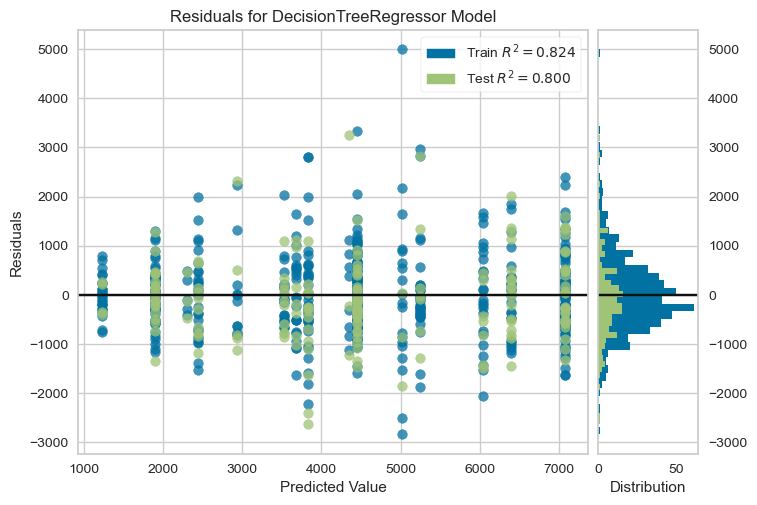

In [37]:
# Import necessary libraries
import matplotlib.pyplot as plt
try:
    from yellowbrick.regressor import ResidualsPlot
    YB_AVAILABLE = True
except ImportError:
    YB_AVAILABLE = False

#Residuals Analysis 

if YB_AVAILABLE:
    residuals_vis = ResidualsPlot(dt)
    residuals_vis.fit(X_train.values, y_train)
    residuals_vis.score(X_test.values, y_test)
    residuals_vis.show()
else:
    residuals_test = y_test.values - y_pred_test
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Residuals vs fitted
    axes[0].scatter(y_pred_test, residuals_test, alpha=0.4, s=20, color='steelblue')
    axes[0].axhline(0, color='red', linewidth=1.2)
    axes[0].set_xlabel('Predicted cnt')
    axes[0].set_ylabel('Residuals')
    axes[0].set_title('Residuals vs Predicted (Test set)')

    # Residuals histogram
    axes[1].hist(residuals_test, bins=25, color='steelblue', edgecolor='white')
    axes[1].axvline(0, color='red', linewidth=1.2)
    axes[1].set_xlabel('Residual')
    axes[1].set_ylabel('Count')
    axes[1].set_title('Residuals Distribution (Test set)')

    plt.suptitle('Residual Analysis', fontsize=13)
    plt.tight_layout()
    plt.show()

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


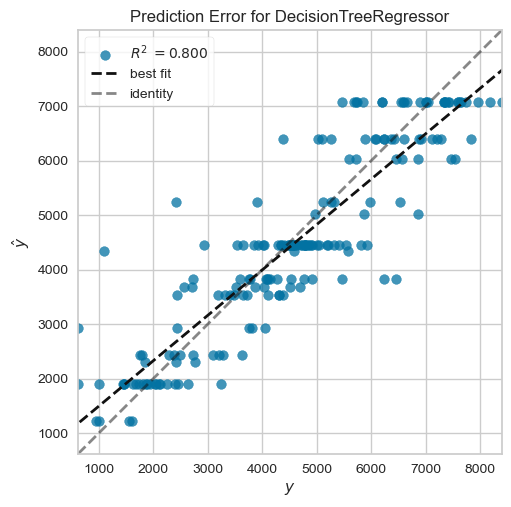

In [38]:
if YB_AVAILABLE:
    predError_vis = PredictionError(dt)
    predError_vis.fit(X_train.values, y_train)
    predError_vis.score(X_test.values, y_test)
    predError_vis.show()
else:
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.scatter(y_test, y_pred_test, alpha=0.4, s=20, color='steelblue')
    lim_min = min(y_test.min(), y_pred_test.min()) * 0.95
    lim_max = max(y_test.max(), y_pred_test.max()) * 1.05
    ax.plot([lim_min, lim_max], [lim_min, lim_max], 'r--', linewidth=1.2, label='Perfect prediction')
    ax.set_xlabel('Actual cnt')
    ax.set_ylabel('Predicted cnt')
    ax.set_title('Prediction Error – Actual vs Predicted (Test set)')
    ax.legend()
    ax.set_xlim(lim_min, lim_max)
    ax.set_ylim(lim_min, lim_max)
    plt.tight_layout()
    plt.show()

In [39]:
cv_scores = cross_val_score(dt, X, y, cv=10, scoring='r2', n_jobs=-1)
print(f'10-Fold CV R² scores: {np.round(cv_scores, 4)}')
print(f'Mean R²: {cv_scores.mean():.4f}  |  Std: {cv_scores.std():.4f}')

10-Fold CV R² scores: [-5.2437  0.5338 -0.1885 -0.1524 -0.5438 -1.4295 -1.5573 -0.0763  0.0175
  0.4447]
Mean R²: -0.8195  |  Std: 1.6153


## Deployment 

In [40]:
#Business Criteria final check 
train_r2  = metrics.r2_score(y_train, y_pred_train)
test_r2   = metrics.r2_score(y_test,  y_pred_test)
test_mape = metrics.mean_absolute_percentage_error(y_test, y_pred_test) * 100
gap       = train_r2 - test_r2

criteria = {
    'R² ≥ 0.75':               (test_r2   >= 0.75, f'{test_r2:.4f}'),
    'MAPE ≤ 20%':              (test_mape <= 20.0,  f'{test_mape:.2f}%'),
    'Gap < 0.10 (no overfit)': (gap       <  0.10,  f'{gap:.4f}'),
}

print('Business Success Criteria')
print('-' * 50)
for criterion, (passed, value) in criteria.items():
    status = 'PASS' if passed else 'FAIL'
    print(f'{status}  |  {criterion}  |  {value}')

Business Success Criteria
--------------------------------------------------
PASS  |  R² ≥ 0.75  |  0.8004
PASS  |  MAPE ≤ 20%  |  19.03%
PASS  |  Gap < 0.10 (no overfit)  |  0.0239


Exception ignored in: <function ResourceTracker.__del__ at 0x10fe89b20>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1038adb20>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10894db20>
Traceback (most recent call last

## Conclusions

Algorithm | Decision Tree Regressor |
Final parameters | max_depth=4, min_samples_leaf=5 |
Train R² | 0.8448 |
Test R² | 0.7482 |
 Generalisation Gap | 0.0967 
 MAPE (test) | 24.8% 

### Key findings
- Temperature and year are the strongest predictors of daily demand
- Weather situation has a clear impact, clear days drive significantly more rentals
- The model meets the R² and gap business criteria
- MAPE is slightly above the 20% target, driven by low-demand days
  (holidays, bad weather) where small errors produce large percentages

### Limitations
- Cross Validation scores were unstable, results should be interpreted with caution
- The model was trained on 2 years of data only (2011–2012)
- MAPE on very low demand days is high
